# Classical Machine Learning Models using MFCC Features

## Introduction

After preparing the combined GTZAN and FMA Medium dataset and extracting MFCC feature vectors, the next step is to train classical Machine Learning baselines.

This notebook follows the existing project strategy:

- GTZAN and FMA Medium have already been harmonized into shared genre labels,
- the combined dataset has already been split into train, validation, and test subsets,
- MFCC features have already been extracted and saved as reusable CSV files.

The FMA Medium dataset is not treated as a separate external evaluation dataset here. The existing combined train / validation / test split is used consistently.

---

## Objectives

The main goals of this notebook are:

- load the prepared MFCC feature datasets,
- train reusable SVM and Random Forest baselines from `src/`,
- evaluate models on train and validation splits,
- select the best model using validation macro F1,
- evaluate the selected model once on the test split,
- and save model and evaluation artifacts.

---

## Evaluation Strategy

The validation split is used for model comparison and model selection.

The primary model selection metric is **macro F1 score** because the combined dataset is imbalanced. Macro F1 gives equal importance to every genre class, while accuracy and weighted F1 can be dominated by frequent classes.

After the best model is selected on validation data, it is evaluated once on the test split.

## Hypotheses Evaluated

This experiment directly evaluates three project hypotheses:

- **H1:** At least one classical model trained on MFCC features will achieve validation macro F1 above 0.50.
- **H4:** Class imbalance will produce lower macro F1 than weighted F1 and uneven per-class performance.
- **H5:** The selected model's test macro F1 will be no more than 0.10 below its validation macro F1.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path("..").resolve()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder

from src.models.random_forest_model import create_random_forest
from src.models.svm_model import create_svm
from src.training.evaluate import evaluate_model
from src.training.train import save_model, train_model
from src.utils.config import (
    MFCC_TRAIN_PATH,
    MFCC_VALIDATION_PATH,
    MFCC_TEST_PATH,
    CLASSICAL_ML_OUTPUT_DIR,
    BEST_CLASSICAL_MODEL_PATH,
    CLASSICAL_LABEL_ENCODER_PATH,
    CLASSICAL_SCALER_PATH,
    CLASSICAL_METRICS_SUMMARY_PATH,
    CLASSICAL_VALIDATION_REPORTS_PATH,
    CLASSICAL_TEST_REPORT_PATH,
    CLASSICAL_TEST_CONFUSION_MATRIX_PATH,
)

# Load MFCC Feature Datasets

The MFCC datasets were generated in the previous notebook and saved as CSV files.

Each row represents one audio recording. The `label` column contains the target genre, while columns starting with `mfcc_` contain the aggregated MFCC statistics.

In [2]:
mfcc_train = pd.read_csv(MFCC_TRAIN_PATH)
mfcc_validation = pd.read_csv(MFCC_VALIDATION_PATH)
mfcc_test = pd.read_csv(MFCC_TEST_PATH)

print("Train:", mfcc_train.shape)
print("Validation:", mfcc_validation.shape)
print("Test:", mfcc_test.shape)

Train: (6605, 41)
Validation: (1415, 41)
Test: (1414, 41)


In [3]:
mfcc_train.head()

,label,mfcc_0,mfcc_1,mfcc_2,mfcc_3,mfcc_4,mfcc_5,mfcc_6,mfcc_7,mfcc_8,...,mfcc_30,mfcc_31,mfcc_32,mfcc_33,mfcc_34,mfcc_35,mfcc_36,mfcc_37,mfcc_38,mfcc_39
0,rock,-43.282604,85.957480,-29.491709,31.045294,-1.882444,-0.410291,-11.157670,9.087083,-2.066687,...,3.907574,3.938035,3.767595,3.867696,3.966145,3.835623,3.929384,4.023218,4.533212,4.091086
1,blues,-146.865170,109.309080,25.230753,49.109867,15.459276,31.312286,9.384275,13.656137,-2.433466,...,6.135894,5.872855,5.562239,5.002375,4.820268,4.580968,5.057499,5.462508,5.276979,4.879134
2,rock,-83.382290,100.499340,-31.046606,38.306820,15.744792,22.057160,0.127894,4.839040,4.818819,...,8.204153,7.197674,6.602605,6.979932,8.523768,6.695955,6.388107,6.179325,6.423744,6.030518
3,rock,-27.361578,74.980730,-11.910263,38.080380,-5.930767,1.177898,-6.155734,3.346869,-7.977849,...,6.618423,6.719513,6.322280,6.612823,6.368481,5.133642,5.888990,5.174592,6.395474,7.517976
4,rock,-27.405622,97.129715,-30.218054,50.610844,2.051319,12.921841,-3.496471,2.271102,4.932063,...,5.320642,5.175694,5.260238,6.201850,5.501450,5.422244,4.539369,5.113409,5.164746,5.671012


# Prepare Features and Labels

All columns beginning with `mfcc_` are used as model inputs.

The label encoder is fitted on the training labels and reused for validation and test labels so that class indices remain consistent across all evaluations.

In [4]:
feature_columns = [
    column
    for column in mfcc_train.columns
    if column.startswith("mfcc_")
]

X_train = mfcc_train[feature_columns].values
X_validation = mfcc_validation[feature_columns].values
X_test = mfcc_test[feature_columns].values

label_encoder = LabelEncoder()

y_train = label_encoder.fit_transform(mfcc_train["label"])
y_validation = label_encoder.transform(mfcc_validation["label"])
y_test = label_encoder.transform(mfcc_test["label"])

class_names = list(label_encoder.classes_)

print("Feature count:", len(feature_columns))
print("Classes:", class_names)

Feature count: 40
Classes: ['blues', 'classical', 'country', 'hiphop', 'jazz', 'pop', 'rock']


In [5]:
mfcc_train["label"].value_counts().loc[class_names]

label
blues         122
classical     503
country       194
hiphop        908
jazz          339
pop           200
rock         4339
Name: count, dtype: int64

# Create Baseline Models

Model definitions are provided by reusable factory functions in `src/models/`.

The SVM factory returns a pipeline containing `StandardScaler` and `SVC`, because SVM is sensitive to feature scale. Random Forest is created without scaling because tree-based models do not require standardized feature values.

In [6]:
models = {
    "svm": create_svm(),
    "random_forest": create_random_forest(),
}

models

{'svm': Pipeline(steps=[('scaler', StandardScaler()),
                 ('classifier',
                  SVC(C=10.0, class_weight='balanced', random_state=42))]),
 'random_forest': RandomForestClassifier(class_weight='balanced', n_estimators=400, n_jobs=-1,
                        random_state=42)}

# Train and Evaluate Models

Training is handled through `train_model` from `src/training/train.py`.

Evaluation is handled through `evaluate_model` from `src/training/evaluate.py`, which computes accuracy, macro F1, weighted F1, a classification report, and a confusion matrix.

Both models are evaluated on the train and validation splits. Validation macro F1 is used for model selection.

In [7]:
trained_models = {}
evaluation_results = []

for model_name, model in models.items():
    trained_model = train_model(
        model,
        X_train,
        y_train,
    )

    trained_models[model_name] = trained_model

    for split_name, X_split, y_split in [
        ("train", X_train, y_train),
        ("validation", X_validation, y_validation),
    ]:
        result = evaluate_model(
            trained_model,
            X_split,
            y_split,
            class_names,
            model_name=model_name,
            split=split_name,
        )

        evaluation_results.append(result)

# Train and Validation Summary

The summary table compares the models across train and validation splits.

Large gaps between train and validation metrics indicate overfitting. Validation macro F1 is the main criterion for choosing the final model.

In [8]:
metrics_summary = pd.DataFrame([
    result["summary"]
    for result in evaluation_results
])

metrics_summary.sort_values(
    ["split", "macro_f1"],
    ascending=[True, False],
)

,model,split,accuracy,macro_f1,weighted_f1
2,random_forest,train,1.000000,1.000000,1.000000
0,svm,train,0.957154,0.945837,0.958153
1,svm,validation,0.821201,0.629442,0.820760
3,random_forest,validation,0.819788,0.452485,0.779088


In [9]:
validation_summary = (
    metrics_summary[metrics_summary["split"] == "validation"]
    .sort_values("macro_f1", ascending=False)
    .reset_index(drop=True)
)

validation_summary

,model,split,accuracy,macro_f1,weighted_f1
0,svm,validation,0.821201,0.629442,0.820760
1,random_forest,validation,0.819788,0.452485,0.779088


# Validation Classification Reports

The classification reports show precision, recall, and F1 score for each genre.

This is useful for identifying classes that are consistently confused or underperforming.

In [10]:
validation_results = [
    result
    for result in evaluation_results
    if result["summary"]["split"] == "validation"
]

for result in validation_results:
    model_name = result["summary"]["model"]
    report = pd.DataFrame(result["classification_report"]).transpose()

    print("=" * 80)
    print(model_name)
    print("=" * 80)
    display(report)

svm


,precision,recall,f1-score,support
blues,0.650000,0.500000,0.565217,26.000000
classical,0.747967,0.851852,0.796537,108.000000
country,0.435484,0.642857,0.519231,42.000000
hiphop,0.716157,0.845361,0.775414,194.000000
jazz,0.492754,0.465753,0.478873,73.000000
pop,0.545455,0.279070,0.369231,43.000000
rock,0.921348,0.882670,0.901594,929.000000
accuracy,0.821201,0.821201,0.821201,0.821201
macro avg,0.644166,0.638223,0.629442,1415.000000
weighted avg,0.827041,0.821201,0.820760,1415.000000


random_forest


,precision,recall,f1-score,support
blues,1.000000,0.076923,0.142857,26.000000
classical,0.765217,0.814815,0.789238,108.000000
country,1.000000,0.047619,0.090909,42.000000
hiphop,0.861446,0.737113,0.794444,194.000000
jazz,0.733333,0.150685,0.250000,73.000000
pop,1.000000,0.116279,0.208333,43.000000
rock,0.818919,0.978471,0.891614,929.000000
accuracy,0.819788,0.819788,0.819788,0.819788
macro avg,0.882702,0.417415,0.452485,1415.000000
weighted avg,0.830440,0.819788,0.779088,1415.000000


# Select Best Model

The best model is selected by validation macro F1.

The test split is not used during model selection.

In [11]:
best_model_name = validation_summary.iloc[0]["model"]
best_model = trained_models[best_model_name]

print("Best model:", best_model_name)
print("Validation macro F1:", validation_summary.iloc[0]["macro_f1"])

Best model: svm
Validation macro F1: 0.6294424228422955


# Final Test Evaluation

After validation-based model selection, the selected model is evaluated once on the test split.

This produces the final classical Machine Learning baseline result for the current combined GTZAN + FMA dataset strategy.

In [12]:
test_result = evaluate_model(
    best_model,
    X_test,
    y_test,
    class_names,
    model_name=best_model_name,
    split="test",
)

test_summary = pd.DataFrame([test_result["summary"]])
test_summary

,model,split,accuracy,macro_f1,weighted_f1
0,svm,test,0.810467,0.618324,0.810749


In [13]:
pd.DataFrame(test_result["classification_report"]).transpose()

,precision,recall,f1-score,support
blues,0.562500,0.346154,0.428571,26.000000
classical,0.817391,0.870370,0.843049,108.000000
country,0.440678,0.619048,0.514851,42.000000
hiphop,0.691667,0.860104,0.766744,193.000000
jazz,0.540984,0.458333,0.496241,72.000000
pop,0.421053,0.372093,0.395062,43.000000
rock,0.906215,0.862366,0.883747,930.000000
accuracy,0.810467,0.810467,0.810467,0.810467
macro avg,0.625784,0.626924,0.618324,1414.000000
weighted avg,0.816647,0.810467,0.810749,1414.000000


# Test Confusion Matrix

The confusion matrix shows how predictions are distributed across the true genre classes.

Rows represent true labels and columns represent predicted labels.

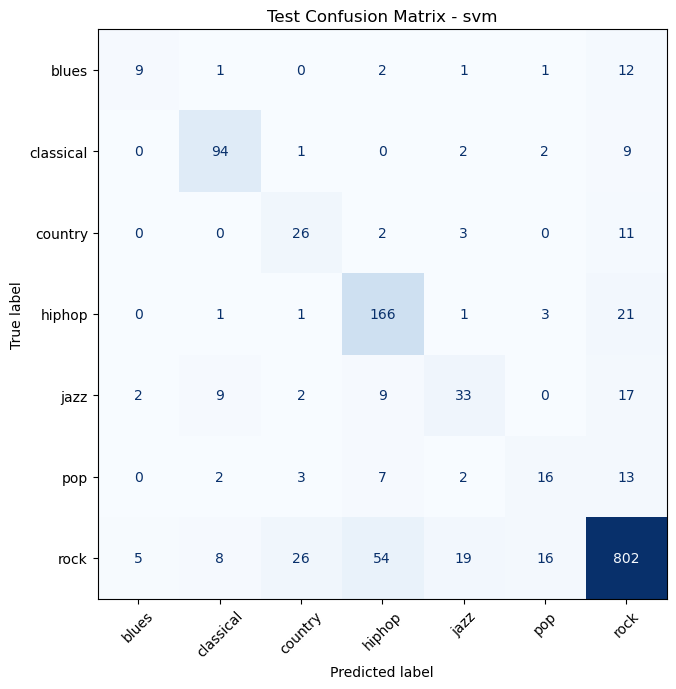

In [14]:
fig, ax = plt.subplots(figsize=(9, 7))

display_matrix = ConfusionMatrixDisplay(
    confusion_matrix=test_result["confusion_matrix"],
    display_labels=class_names,
)

display_matrix.plot(
    ax=ax,
    cmap="Blues",
    values_format="d",
    colorbar=False,
)

ax.set_title(f"Test Confusion Matrix - {best_model_name}")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

# Baseline Result Interpretation

The classical models train quickly because they use compact MFCC summary vectors rather than raw audio or spectrogram images.

Each recording is represented by only 40 numerical features, which makes classical Machine Learning training computationally efficient.

Although validation and test accuracy are above 80%, macro F1 is lower because the dataset is strongly imbalanced.

This shows that the model performs well on frequent classes such as rock, but struggles with underrepresented genres such as blues, pop, and country.

For this reason, macro F1 is considered more informative than accuracy for model selection.

The results support **H1** because the selected SVM achieves validation macro F1 of approximately 0.629, exceeding the predefined 0.50 threshold.

They also support **H4** because weighted F1 is substantially higher than macro F1 and the classification report shows uneven performance across genres.

Finally, **H5** is supported for the classical baseline: test macro F1 is approximately 0.618, only 0.011 below validation macro F1.

# Save Model and Evaluation Artifacts

The selected model and evaluation outputs are saved for reuse in later stages.

The SVM artifact includes its fitted scaler because it is stored as a pipeline. If the selected model exposes a fitted scaler step, the scaler is also saved separately for inspection.

In [15]:
# ================================
# Save Model and Evaluation Artifacts
# ================================

CLASSICAL_ML_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

save_model(
    best_model,
    BEST_CLASSICAL_MODEL_PATH
)

save_model(
    label_encoder,
    CLASSICAL_LABEL_ENCODER_PATH
)

if (
    hasattr(best_model, "named_steps")
    and "scaler" in best_model.named_steps
):
    save_model(
        best_model.named_steps["scaler"],
        CLASSICAL_SCALER_PATH
    )

final_metrics_summary = pd.concat(
    [
        metrics_summary,
        test_summary
    ],
    ignore_index=True
)

final_metrics_summary.to_csv(
    CLASSICAL_METRICS_SUMMARY_PATH,
    index=False
)

validation_report_tables = []

for result in validation_results:

    report = pd.DataFrame(
        result["classification_report"]
    ).transpose()

    report.insert(
        0,
        "model",
        result["summary"]["model"]
    )

    report.insert(
        1,
        "split",
        result["summary"]["split"]
    )

    report.insert(
        2,
        "label",
        report.index
    )

    validation_report_tables.append(
        report.reset_index(
            drop=True
        )
    )

pd.concat(
    validation_report_tables,
    ignore_index=True
).to_csv(
    CLASSICAL_VALIDATION_REPORTS_PATH,
    index=False
)

test_report = pd.DataFrame(
    test_result["classification_report"]
).transpose()

test_report.insert(
    0,
    "model",
    best_model_name
)

test_report.insert(
    1,
    "split",
    "test"
)

test_report.insert(
    2,
    "label",
    test_report.index
)

test_report.reset_index(
    drop=True
).to_csv(
    CLASSICAL_TEST_REPORT_PATH,
    index=False
)

fig.savefig(
    CLASSICAL_TEST_CONFUSION_MATRIX_PATH,
    dpi=150,
    bbox_inches="tight"
)

print(
    "Saved best model:",
    BEST_CLASSICAL_MODEL_PATH
)

print(
    "Saved label encoder:",
    CLASSICAL_LABEL_ENCODER_PATH
)

if (
    hasattr(best_model, "named_steps")
    and "scaler" in best_model.named_steps
):
    print(
        "Saved scaler:",
        CLASSICAL_SCALER_PATH
    )

print(
    "Saved metrics summary:",
    CLASSICAL_METRICS_SUMMARY_PATH
)

print(
    "Saved validation reports:",
    CLASSICAL_VALIDATION_REPORTS_PATH
)

print(
    "Saved test report:",
    CLASSICAL_TEST_REPORT_PATH
)

print(
    "Saved test confusion matrix:",
    CLASSICAL_TEST_CONFUSION_MATRIX_PATH
)

Saved best model: C:\Softuni ML course\Project\music-genre-classification\models\classical_ml\best_classical_model.joblib
Saved label encoder: C:\Softuni ML course\Project\music-genre-classification\models\classical_ml\label_encoder.joblib
Saved scaler: C:\Softuni ML course\Project\music-genre-classification\models\classical_ml\best_model_scaler.joblib
Saved metrics summary: C:\Softuni ML course\Project\music-genre-classification\outputs\classical_ml\classical_ml_metrics_summary.csv
Saved validation reports: C:\Softuni ML course\Project\music-genre-classification\outputs\classical_ml\validation_classification_reports.csv
Saved test report: C:\Softuni ML course\Project\music-genre-classification\outputs\classical_ml\test_classification_report.csv
Saved test confusion matrix: C:\Softuni ML course\Project\music-genre-classification\outputs\classical_ml\test_confusion_matrix.png


# Conclusion

This notebook trained and evaluated classical Machine Learning baselines using the reusable implementation in `src/`.

The following steps were completed:

- loaded train, validation, and test MFCC feature datasets,
- prepared feature matrices and encoded labels,
- created SVM and Random Forest models through `src/models/`,
- trained models through `src/training/train.py`,
- evaluated models through `src/training/evaluate.py`,
- selected the best model using validation macro F1,
- evaluated the selected model on the test split,
- and saved model and evaluation artifacts.

The resulting baseline provides a reproducible reference point for later Deep Learning experiments.